## Dependencias
# Ejecutar este comando para instalar las librerías necesarias
```
penv/Scripts/activate
pip install pandas numpy scikit-learn matplotlib seaborn jinja2
```

In [2]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML

In [5]:
df_inicial = pd.read_csv("/content/bmw_pricing_v3.csv")

In [ ]:
print("Shape:", df_inicial.shape)
df_inicial.head()

Shape: (4843, 18)


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [6]:
df_inicial.isnull().sum()

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


In [19]:
df_inicial.isnull().any()

,0
marca,True
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True


In [8]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [9]:
# Conversión con pd.to_datetime
df_inicial_test = df_inicial.copy()
for i in df_inicial.columns:
    if str(i).upper().startswith('FECHA'):
        df_inicial_test[i] = pd.to_datetime(df_inicial[i])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   marca                        3873 non-null   object        
 1   modelo                       4840 non-null   object        
 2   km                           4841 non-null   float64       
 3   potencia                     4842 non-null   float64       
 4   fecha_registro               2420 non-null   datetime64[ns]
 5   tipo_gasolina                4838 non-null   object        
 6   color                        4398 non-null   object        
 7   tipo_coche                   3383 non-null   object        
 8   volante_regulable            4839 non-null   object        
 9   aire_acondicionado           4357 non-null   object        
 10  camara_trasera               4841 non-null   object        
 11  asientos_traseros_plegables  1452 non-null 

In [10]:
df_inicial_test[df_inicial_test.duplicated(keep='first')].shape

(0, 18)

No hay duplicados

In [11]:
# Porcentaje de nulos
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.0f}% \tde nulos en {i}')

20% 	de nulos en marca
0% 	de nulos en modelo
0% 	de nulos en km
0% 	de nulos en potencia
50% 	de nulos en fecha_registro
0% 	de nulos en tipo_gasolina
9% 	de nulos en color
30% 	de nulos en tipo_coche
0% 	de nulos en volante_regulable
10% 	de nulos en aire_acondicionado
0% 	de nulos en camara_trasera
70% 	de nulos en asientos_traseros_plegables
0% 	de nulos en elevalunas_electrico
15% 	de nulos en bluetooth
0% 	de nulos en gps
15% 	de nulos en alerta_lim_velocidad
0% 	de nulos en precio
0% 	de nulos en fecha_venta


In [12]:
df_inicial_test["marca"].value_counts(dropna=False)

,count
marca,
BMW,3873
NaN,970


Borramos la columna marca debido a que es irrelevante al tratarse todo de BMW

In [13]:
df_inicial_test.drop(columns=['marca'], inplace=True)

In [14]:
df_inicial_test["precio"].describe()

,precio
count,4837.000000
mean,15831.920612
std,9222.630708
min,100.000000
25%,10800.000000
50%,14200.000000
75%,18600.000000
max,178500.000000


Text(0, 0.5, 'Frecuencia')

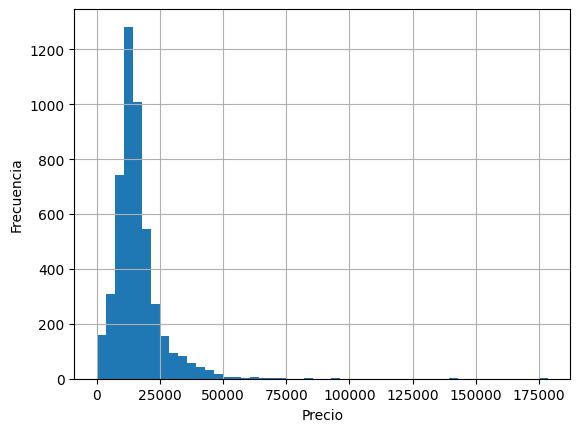

In [15]:
df_inicial_test.precio.hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

In [16]:
def columnas_por_tipo(df, as_dict=False):
    """
    Agrupa las columnas de un DataFrame por tipo y devuelve las listas de nombres de columnas.

    Parámetros:
    - df: pandas.DataFrame
    - as_dict: bool (opcional). Si True devuelve un dict con las listas;
               si False (por defecto) devuelve una tupla con las listas en el
               siguiente orden: (numeric, bools, datetimes, objects, categories,
               timedeltas, complex_cols, ints, floats, others).

    Retorno:
    - Si as_dict=True: dict con claves 'all','numeric','int','float','bool',
      'datetime','object','category','timedelta','complex','others'.
    - Si as_dict=False: tupla de listas: (numeric, bools, datetimes, objects,
      categories, timedeltas, complex_cols, ints, floats, others).

    Ejemplos:
    - numeric, bools, datetimes, objects, categories, timedeltas, complex_cols,
      ints, floats, others = columnas_por_tipo(df)
    - grouped = columnas_por_tipo(df, as_dict=True)
    - df[numeric].head()  # muestra solo columnas numéricas si 'numeric' es la lista
    """
    # columnas por tipos básicos
    numeric = df.select_dtypes(include=['number']).columns.tolist()
    bools = df.select_dtypes(include=['bool']).columns.tolist()
    datetimes = df.select_dtypes(include=['datetime']).columns.tolist()
    objects = df.select_dtypes(include=['object']).columns.tolist()
    categories = df.select_dtypes(include=['category']).columns.tolist()
    timedeltas = df.select_dtypes(include=['timedelta']).columns.tolist()
    complex_cols = df.select_dtypes(include=['complex']).columns.tolist()

    # distinguir int / float dentro de numeric
    ints = [c for c in numeric if pd.api.types.is_integer_dtype(df[c])]
    floats = [c for c in numeric if pd.api.types.is_float_dtype(df[c])]

    grouped = {
        'all': df.columns.tolist(),
        'numeric': numeric,
        'int': ints,
        'float': floats,
        'bool': bools,
        'datetime': datetimes,
        'object': objects,
        'category': categories,
        'timedelta': timedeltas,
        'complex': complex_cols,
    }

    # columnas que no encajan en los grupos anteriores
    grouped_lists = [grouped[k] for k in ['numeric','int','float','bool','datetime','object','category','timedelta','complex']]
    used = set().union(*map(set, grouped_lists)) if grouped_lists else set()
    grouped['others'] = [c for c in df.columns if c not in used]

    if as_dict:
        return grouped

    # devolver las listas en un orden fijo para permitir unpacking directo
    return (numeric, bools, datetimes, objects, categories, timedeltas,
            complex_cols, ints, floats, grouped['others'])

In [17]:
grouped_columns = columnas_por_tipo(df_inicial_test, as_dict=True)
for tipo, columnas in grouped_columns.items():
    print(f"{tipo}: {columnas}")

all: ['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']
numeric: ['km', 'potencia', 'precio']
int: []
float: ['km', 'potencia', 'precio']
bool: ['gps']
datetime: ['fecha_registro', 'fecha_venta']
object: ['modelo', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad']
category: []
timedelta: []
complex: []
others: []


In [18]:
numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others = columnas_por_tipo(df_inicial_test)
df_inicial_test[numeric].head()

,km,potencia,precio
0,140411.0,100.0,11300.0
1,13929.0,317.0,69700.0
2,183297.0,120.0,10200.0
3,128035.0,135.0,25100.0
4,97097.0,160.0,33400.0


## PREGUNTA 1

## PREGUNTA 2

## PREGUNTA 3

## PREGUNTA 4

## PREGUNTA 5

## PREGUNTA 6

## PREGUNTA 7

## PREGUNTA 8

##PREGUNTA 9

## PREGUNTA 10